In [2]:
# from atmospheric_analysis import AtmosphericDiagnostics
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os

In [68]:
import numpy as np
import dask.array as da
from dask.diagnostics import ProgressBar

class AtmosphericDiagnostics:
    """
    Perform general atmospheric diagnostics including:
    - Anomalies
    - Eddy Momentum Flux (EMF)
    - Eddy Heat Flux (EHF)
    - Meridional EMF gradient (dEMF/dy)
    """

    def __init__(self, u, v, t, p, lat=None, lon=None):
        """
        Parameters:
        - u, v, t, p: Arrays (NumPy or Dask) of shape (time, z, y, x)
        - lat, lon: Optional 1D arrays for latitude and longitude
        """
        self.u = u
        self.v = v
        self.t = t
        self.p = p

        self.time_dim, self.z_dim, self.y_dim, self.x_dim = u.shape
        self.lat = lat if lat is not None else np.linspace(-90, 90, self.y_dim)
        self.lon = lon if lon is not None else np.linspace(0, 360, self.x_dim)

    @staticmethod
    def anomaly(data, axis=-1):
        """Compute the anomaly by subtracting mean along axis."""
        mean = np.mean(data, axis=axis, keepdims=True)
        return data - mean

    @staticmethod
    def compute_if_dask(arr):
        """Compute the result if it's a Dask array."""
        return arr.compute() if isinstance(arr, da.Array) else arr

    @staticmethod
    def EMF_dask(u, v, axis=-1):
        """Eddy Momentum Flux: u'v' (Dask-compatible)."""
        u_prime = u - u.mean(axis=axis, keepdims=True)
        v_prime = v - v.mean(axis=axis, keepdims=True)
        return u_prime * v_prime
        
    @staticmethod
    def cal_theta(t, p, axis=-1):
        """Eddy Heat Flux: v'b' (Dask-compatible)."""
        Rd, Cp = 287.0, 1004.0
        exponent = Rd / Cp

        theta = t * (100000 / p) ** exponent
        return theta
        

    @staticmethod
    def EHF_dask(t, p, v, axis=-1):
        """Eddy Heat Flux: v'b' (Dask-compatible)."""
        # Rd, Cp = 287.0, 1004.0
        # exponent = Rd / Cp

        # theta = t * (100000 / p) ** exponent
        theta = AtmosphericDiagnostics.cal_theta(t, p)  
        theta_mean = theta.mean(axis=axis, keepdims=True)
        theta_prime = theta - theta_mean

        v_prime = v - v.mean(axis=axis, keepdims=True)
        b = (theta_prime / theta_mean) * 9.81
        b_prime = b - b.mean(axis=axis, keepdims=True)

        return v_prime * b_prime

    # def dEMF_dy(self, emf, use_dask=False):
    #     """
    #     Compute meridional gradient of EMF (∂(u'v')/∂y).
        
    #     Parameters:
    #     - emf: Array of shape (z, y, x)
    #     - use_dask: If True, compute gradient lazily using Dask

    #     Returns:
    #     - dEMF/dy: Array (NumPy or Dask depending on input)
    #     """
    #     R = 6.371e6
    #     lat_rad = np.radians(self.lat)
    #     dy = np.gradient(lat_rad) * R  # meters

    #     dy_broadcast = dy[np.newaxis, :, np.newaxis]

    #     if use_dask and isinstance(emf, da.Array):
    #         return emf.map_blocks(np.gradient, axis=-2) / dy_broadcast
    #     else:
    #         return np.gradient(emf, axis=-2) / dy_broadcast
    def dEMF_dy(self, emf, use_dask=True, progress=True, chunks=(10, 20, 64, 128)):
        """
        Efficient + accurate meridional gradient of EMF (∂(u'v')/∂y) with Dask support.
    
        Parameters:
        - emf: Array (time, z, y, x), either NumPy or Dask
        - use_dask: If True, compute using Dask (lazy until .compute())
        - progress: If True and use_dask is True, show progress bar
        - chunks: Tuple to use if converting NumPy array to Dask
    
        Returns:
        - dEMF_dy: NumPy array if computed, or Dask array if lazy
        """
        # Ensure emf is a Dask array
        emf_dask = da.from_array(emf, chunks=chunks) if not isinstance(emf, da.Array) else emf
    
        # Compute dy between latitudes in meters
        R = 6.371e6
        lat_rad = np.radians(self.lat)
        dy = np.gradient(lat_rad) * R  # shape (y,)
        dy_dask = da.from_array(dy, chunks=(chunks[2],))
        dy_broadcast = dy_dask[None, None, :, None]  # shape (1, 1, y, 1)
    
        # Compute meridional gradient using Dask
        d_emf_dy = da.gradient(emf_dask, axis=2) / dy_broadcast
    
        if use_dask:
            if progress:
                from dask.diagnostics import ProgressBar
                print("dEMF_dy progress:")
                with ProgressBar():
                    return d_emf_dy.compute()
            else:
                return d_emf_dy  # Lazy result
        else:
            # Fallback to NumPy gradient
            emf_np = emf.compute() if isinstance(emf, da.Array) else emf
            dy_np = dy[np.newaxis, :, np.newaxis]
            return np.gradient(emf_np, axis=2) / dy_np



    def run_emf_ehf(self, chunks=(10, 20, 64, 128), progress=True):
        """
        Convert inputs to Dask, compute EMF and EHF with optional progress bar.
        Returns computed NumPy arrays: emf, ehf
        """
        # Convert to Dask arrays if not already
        u_dask = da.from_array(self.u, chunks=chunks) if not isinstance(self.u, da.Array) else self.u
        v_dask = da.from_array(self.v, chunks=chunks) if not isinstance(self.v, da.Array) else self.v
        t_dask = da.from_array(self.t, chunks=chunks) if not isinstance(self.t, da.Array) else self.t
        p_dask = da.from_array(self.p, chunks=chunks) if not isinstance(self.p, da.Array) else self.p

        # Compute EMF & EHF lazily
        emf_lazy = self.EMF_dask(u_dask, v_dask)
        ehf_lazy = self.EHF_dask(t_dask, p_dask, v_dask)

        # Compute with progress bar
        if progress:
            print("EMF and EHF progress:")
            with ProgressBar():
                emf = emf_lazy.compute()
                ehf = ehf_lazy.compute()
        else:
            emf = emf_lazy.compute()
            ehf = ehf_lazy.compute()

        return emf, ehf

    def dtheta(self, theta, save=False, zonal_mean=True, output_dir=None, pr_id=None):
        """
        Compute vertical gradient of potential temperature ∂θ/∂z using central difference.
    
        Parameters:
        - theta: ndarray, shape (time, z, y, x)
        - save: bool, whether to save outputs as HDF5
        - zonal_mean: bool, whether to also compute and return zonal mean
        - output_dir: required if save=True, base path to save files
        - pr_id: required if save=True, identifier like 'PR10'
    
        Returns:
        - dtheta: ndarray, shape (time, z, y, x)
        - dtheta_zonal_mean: ndarray (time, z, y) if zonal_mean=True, else None
        """
        import os
        import gc
        import h5py
    
        print("Computing ∂θ/∂z ...")
        theta = np.asarray(theta)  # ensure numpy array
        t, z, y, x = theta.shape
    
        # Reorder to (t, x, y, z) for vertical diff
        theta_txyz = np.einsum("tzyx->txyz", theta)
        theta_flat = theta_txyz.reshape(t * x * y, z)
    
        # Central and backward diff operators
        L = np.eye(z)
        central = np.roll(L, -1, axis=0) - np.roll(L, 1, axis=0)
        backward = L - np.roll(L, -1, axis=1)
    
        dtheta = theta_flat @ central
        dtheta_b = theta_flat @ backward
        dtheta[:, 0] = dtheta_b[:, 0]
        dtheta[:, -1] = dtheta_b[:, -2]
        del theta_flat, dtheta_b
        gc.collect()
    
        # Reshape back to original layout
        dtheta = dtheta.reshape(t, x, y, z)
        dtheta = np.einsum("txyz->tzyx", dtheta)  # (t, z, y, x)
    
        if zonal_mean:
            zonal = dtheta.mean(axis=3)         # (t, z, y)
            ref_mean = dtheta.mean(axis=(0, 3)) # (z, y)
    
            for i in range(zonal.shape[0]):
                mask = zonal[i] < 0
                zonal[i][mask] = ref_mean[mask]
            del ref_mean
            gc.collect()
        else:
            zonal = None
    
        if save:
            assert output_dir and pr_id, "Both output_dir and pr_id required if save=True"
            save_path = os.path.join(output_dir, pr_id, "dtheta")
            os.makedirs(save_path, exist_ok=True)
    
            with h5py.File(os.path.join(save_path, f"{pr_id}_dtheta_full.h5"), "w") as f:
                f.create_dataset("dtheta", data=dtheta)
            if zonal:
                with h5py.File(os.path.join(save_path, f"{pr_id}_dtheta_zonal_mean.h5"), "w") as f:
                    f.create_dataset("dtheta", data=zonal)
    
            print(f"Saved ∂θ/∂z to {save_path}")
    
        return dtheta



# Read data

In [3]:
u_file = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/u/PR0_500_20000day_6hourly_u.dat"
v_file = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/v/PR0_500_20000day_6hourly_v.dat"

t_file = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/t/PR0_500_20000day_6hourly_t.dat"
p_file = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/p/PR0_500_20000day_6hourly_p.dat"
ps_file = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/ps/PR0_500_20000day_6hourly_ps.dat"





In [4]:
def daily_mean(var_6hourly):
    # Assumes input is (time, z, y, x)
    nt, nz, ny, nx = var_6hourly.shape

    # Ensure time dimension is divisible by 4
    n_days = nt // 4
    var_6hourly = var_6hourly[:n_days * 4]  # truncate if needed

    # Reshape and average every 4 time steps
    var_daily = var_6hourly.reshape(n_days, 4, nz, ny, nx).mean(axis=1)
    return var_daily


In [5]:
with h5py.File(u_file, "r") as ds:
    u = np.asarray(ds["u"][5000*4:5000*4 + 10000*4])
    # u_daily = daily_mean(u)

with h5py.File(v_file, "r") as ds:
    v = np.asarray(ds["v"][5000*4:5000*4 + 10000*4])
    # v_daily = daily_mean(v)

with h5py.File(t_file, "r") as ds:
    t = np.asarray(ds["t"][5000*4:5000*4 + 10000*4])
    # t_daily = daily_mean(t)

with h5py.File(p_file, "r") as ds:
    p = np.asarray(ds["p"][5000*4:5000*4 + 10000*4])
    # p_daily = daily_mean(p)

    

In [6]:
u.shape

(40000, 20, 64, 128)

In [62]:
# Assume u, v, t, p are large NumPy arrays
diagnostics = AtmosphericDiagnostics(u, v, t, p)

# Compute EMF and EHF with Dask
emf, ehf = diagnostics.run_emf_ehf(chunks=(10, 20, 64, 128))

# Assume emf has shape (78000, 20, 64, 128) and is a NumPy array
diagnostics = AtmosphericDiagnostics(u, v, t, p)
d_emf_dy = diagnostics.dEMF_dy(emf, use_dask=True, progress=True)

EMF and EHF progress:
[########################################] | 100% Completed | 8.66 ss
[########################################] | 100% Completed | 28.22 s
dEMF_dy progress:
[########################################] | 100% Completed | 8.39 sms


(20.0, 0.0)

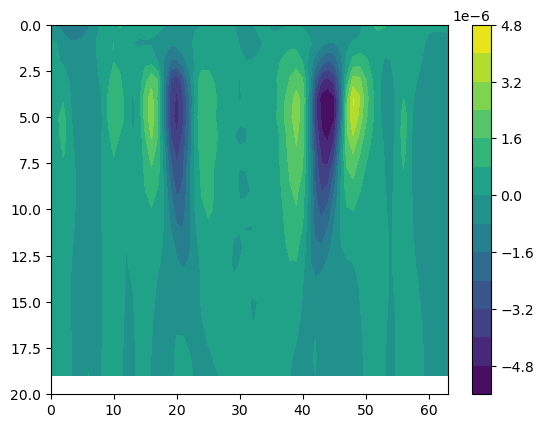

In [63]:
plt.figure()
plt.contourf(d_emf_dy.mean(axis=(0,3)), levels=11)
plt.colorbar()
plt.ylim([20,0])

In [64]:
diagnostics = AtmosphericDiagnostics(u, v, t, p)
theta       = diagnostics.cal_theta(t, p)


In [65]:
theta.shape

(40000, 20, 64, 128)

(20.0, 0.0)

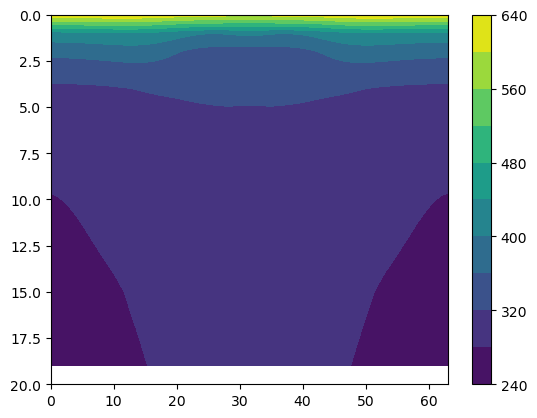

In [66]:
plt.figure()
plt.contourf(theta.mean(axis=(0,-1)), levels=11)
plt.colorbar()
plt.ylim([20,0])

In [70]:
diagnostics = AtmosphericDiagnostics(u, v, t, p)
dtheta       = diagnostics.dtheta(theta)

Computing ∂θ/∂z ...


In [71]:
dtheta.shape

(40000, 20, 64, 128)

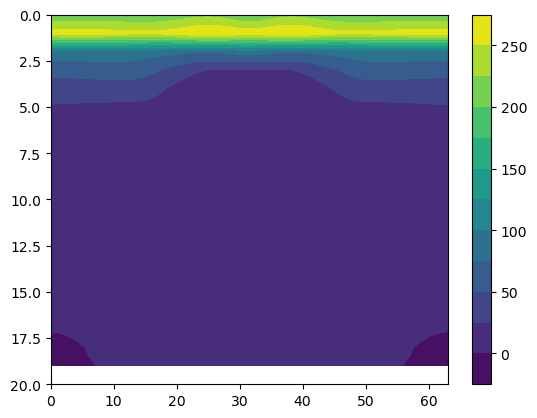

In [74]:
plt.figure()
plt.contourf(dtheta.mean(axis=(0,-1)), levels=11)
plt.colorbar()
plt.ylim([20,0])

plt.show()